# Exploración: Importación de Vehículos — SAT Guatemala (2025–2026)

## Repositorio: https://github.com/AscencioSIUU/dataScience.git

**Fuente:** Portal SAT — Alza e Importación de Vehículos  
**Datos:** `Datos/importacion_vehiculos_2025_2026.csv`  
**Requisito previo:** ejecutar `python descargar_datos.py` antes de abrir este notebook.

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Configuración de gráficas
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

os.makedirs("Datos", exist_ok=True)

# Cargar datos
df = pd.read_csv(
    "Datos/importacion_vehiculos_2025_2026.csv",
    parse_dates=["Fecha de la Poliza"],
    low_memory=False,
)

print(f"Total de filas: {len(df):,}")
print(f"Columnas: {list(df.columns)}")
df.head(3)

Total de filas: 1,078,487
Columnas: ['Pais de Proveniencia', 'Aduana de Ingreso', 'Fecha de la Poliza', 'Partida Arancelaria', 'Modelo del Vehiculo', 'Marca', 'Linea', 'Centimetros Cubicos', 'Distintivo', 'Tipo de Vehiculo', 'Tipo de Importador', 'Tipo Combustible', 'Asientos', 'Puertas', 'Tonelaje', 'Valor CIF', 'Impuesto', 'anio_archivo', 'mes_archivo']


,Pais de Proveniencia,Aduana de Ingreso,Fecha de la Poliza,Partida Arancelaria,Modelo del Vehiculo,Marca,Linea,Centimetros Cubicos,Distintivo,Tipo de Vehiculo,Tipo de Importador,Tipo Combustible,Asientos,Puertas,Tonelaje,Valor CIF,Impuesto,anio_archivo,mes_archivo
0,TECUN UMAN,10/01/2025,NaT,1974,PETERBILT,359-A,14000.0,PESADO,CAMION VOLTEO,OCASIONAL,DIESEL,2.0,2.0,20.0,33325.78,3999.09,NaN,2025,1
1,TECUN UMAN,08/01/2025,NaT,2003,HONDA,CR-V EX 4WD,2400.0,LIVIANO,CAMIONETA,OCASIONAL,GASOLINA,5.0,4.0,0.0,42759.58,5131.15,NaN,2025,1
2,TECUN UMAN,08/01/2025,NaT,1994,TOYOTA,REG CAB 4X2,2400.0,LIVIANO,PICK UP,OCASIONAL,GASOLINA,3.0,2.0,1.0,32527.90,3903.35,NaN,2025,1


---
## Pregunta 1 — ¿Cuántos vehículos livianos de cada tipo se importaron en 2025?

Empty DataFrame
Columns: [Tipo de Vehículo, Total]
Index: []


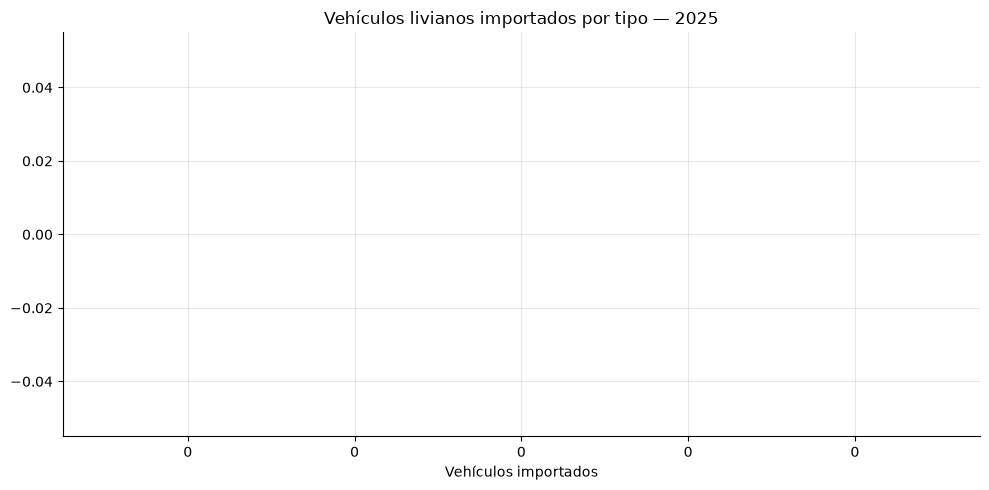

In [6]:
livianos_2025 = df[(df["Distintivo"] == "LIVIANO") & (df["anio_archivo"] == 2025)]

conteo = (
    livianos_2025["Tipo de Vehiculo"]
    .value_counts()
    .reset_index()
    .rename(columns={"Tipo de Vehiculo": "Tipo de Vehículo", "count": "Total"})
)
print(conteo.to_string(index=False))

fig, ax = plt.subplots()
ax.barh(conteo["Tipo de Vehículo"], conteo["Total"], color="steelblue")
ax.set_xlabel("Vehículos importados")
ax.set_title("Vehículos livianos importados por tipo — 2025")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("Datos/p1_livianos_por_tipo_2025.png", dpi=120)
plt.show()

---
## Pregunta 2 — Distribución de modelos (año) de carros, pickups y SUV importados en 2025

Top 5 años de modelo por tipo de vehículo (2025):

AUTOMOVIL
Empty DataFrame
Columns: [Tipo de Vehiculo, Modelo del Vehiculo, Total]
Index: []

PICK UP
Empty DataFrame
Columns: [Tipo de Vehiculo, Modelo del Vehiculo, Total]
Index: []

SUV
Empty DataFrame
Columns: [Tipo de Vehiculo, Modelo del Vehiculo, Total]
Index: []


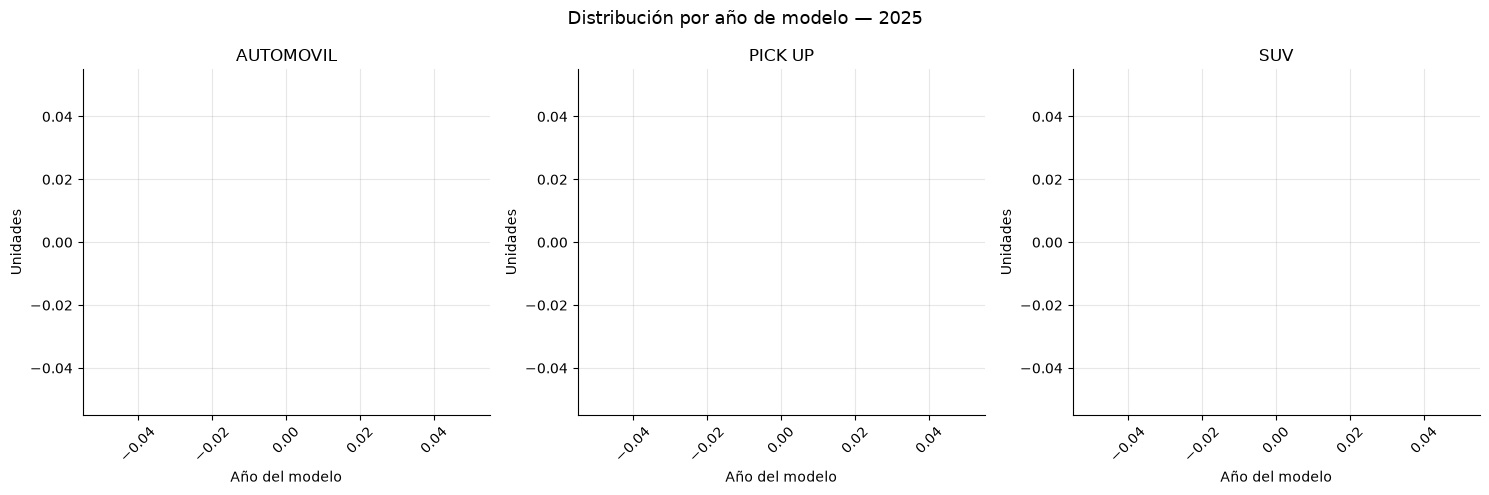

In [7]:
TIPOS_INTERES = ["AUTOMOVIL", "PICK UP", "SUV"]

base = df[
    (df["anio_archivo"] == 2025)
    & (df["Tipo de Vehiculo"].isin(TIPOS_INTERES))
].copy()

# 'Modelo del Vehiculo' contiene el año del modelo (ej. 2024, 2023)
base["Modelo del Vehiculo"] = pd.to_numeric(base["Modelo del Vehiculo"], errors="coerce")
base = base.dropna(subset=["Modelo del Vehiculo"])
base["Modelo del Vehiculo"] = base["Modelo del Vehiculo"].astype(int)

dist = (
    base.groupby(["Tipo de Vehiculo", "Modelo del Vehiculo"])
    .size()
    .reset_index(name="Total")
    .sort_values(["Tipo de Vehiculo", "Modelo del Vehiculo"])
)

# Tabla resumen: top 5 modelos por tipo
print("Top 5 años de modelo por tipo de vehículo (2025):")
for tipo in TIPOS_INTERES:
    sub = dist[dist["Tipo de Vehiculo"] == tipo].nlargest(5, "Total")
    print(f"\n{tipo}")
    print(sub.to_string(index=False))

# Gráfica: histograma por tipo
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, tipo in zip(axes, TIPOS_INTERES):
    sub = dist[dist["Tipo de Vehiculo"] == tipo]
    ax.bar(sub["Modelo del Vehiculo"], sub["Total"], color="steelblue", width=0.7)
    ax.set_title(tipo)
    ax.set_xlabel("Año del modelo")
    ax.set_ylabel("Unidades")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Distribución por año de modelo — 2025", fontsize=13)
plt.tight_layout()
plt.savefig("Datos/p2_distribucion_modelos_2025.png", dpi=120)
plt.show()

---
## Pregunta 3 — ¿Cuál es el tipo de vehículo liviano que más se importó en 2025?

In [8]:
conteo_tipo = livianos_2025["Tipo de Vehiculo"].value_counts()
mas_importado = conteo_tipo.idxmax()
cantidad = conteo_tipo.max()

print(f"Tipo de vehículo liviano más importado en 2025: {mas_importado} ({cantidad:,} unidades)")
print(f"  Representa el {100 * cantidad / conteo_tipo.sum():.1f}% del total de livianos.")

ValueError: attempt to get argmax of an empty sequence

---
## Pregunta 4 — ¿En qué meses se importan más vehículos livianos?

Mes  Total 2025
Ene           0
Feb           0
Mar           0
Abr           0
May           0
Jun           0
Jul           0
Ago           0
Sep           0
Oct           0
Nov           0
Dic           0


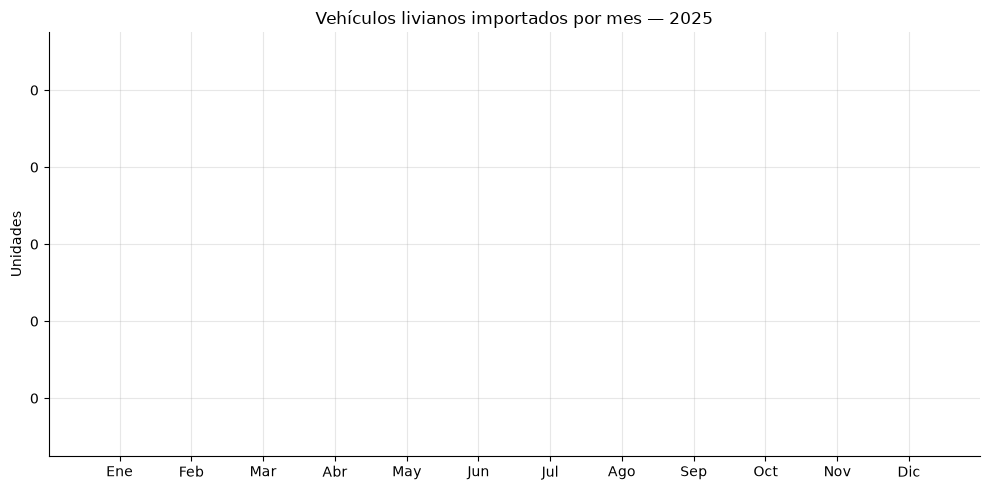


Mes con más importaciones: Ene


In [9]:
MESES_NOMBRES = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
]

livianos = df[df["Distintivo"] == "LIVIANO"]

por_mes = (
    livianos[livianos["anio_archivo"] == 2025]
    .groupby("mes_archivo")
    .size()
    .reindex(range(1, 13), fill_value=0)
)

tabla_mes = pd.DataFrame({
    "Mes": MESES_NOMBRES,
    "Total 2025": por_mes.values
})
print(tabla_mes.to_string(index=False))

fig, ax = plt.subplots()
ax.bar(MESES_NOMBRES, por_mes.values, color="steelblue")
ax.set_title("Vehículos livianos importados por mes — 2025")
ax.set_ylabel("Unidades")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("Datos/p4_importaciones_por_mes.png", dpi=120)
plt.show()

mes_pico = tabla_mes.loc[tabla_mes["Total 2025"].idxmax(), "Mes"]
print(f"\nMes con más importaciones: {mes_pico}")

---
## Pregunta 5 — ¿Cómo van las importaciones en 2026 vs. 2025 (mismo período, enero–junio)?

In [10]:
meses_2026 = sorted(df[df["anio_archivo"] == 2026]["mes_archivo"].unique())
MESES_COMP = meses_2026  # comparar solo los meses disponibles de 2026

periodo = df[
    (df["Distintivo"] == "LIVIANO")
    & (df["mes_archivo"].isin(MESES_COMP))
]

comp = (
    periodo.groupby(["Tipo de Vehiculo", "anio_archivo"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={2025: "2025", 2026: "2026"})
    .sort_values("2025", ascending=False)
)

if "2025" not in comp.columns:
    comp["2025"] = 0
if "2026" not in comp.columns:
    comp["2026"] = 0

comp["Δ%"] = ((comp["2026"] - comp["2025"]) / comp["2025"].replace(0, float("nan")) * 100).round(1)

meses_label = ", ".join([f"{m}" for m in MESES_COMP])
print(f"Comparativa de vehículos livianos — meses {meses_label} (2025 vs 2026):")
print(comp.to_string())

# Gráfica de barras agrupadas
tipos = comp.index.tolist()
x = range(len(tipos))
ancho = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar([i - ancho/2 for i in x], comp["2025"], ancho, label="2025", color="steelblue")
bars2 = ax.bar([i + ancho/2 for i in x], comp["2026"], ancho, label="2026", color="coral")

ax.set_xticks(list(x))
ax.set_xticklabels(tipos, rotation=30, ha="right")
ax.set_ylabel("Unidades")
ax.set_title(f"Importaciones livianos — enero–junio: 2025 vs 2026")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
plt.tight_layout()
plt.savefig("Datos/p5_comparativa_2025_vs_2026.png", dpi=120)
plt.show()

KeyError: '2025'